# Hunga vapor-rich source comparison

This notebook evaluates vapor-rich Hunga source end members using the validated ThermoPlume vapor-only formulation.

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from thermoplume import ThermoPlumeModel, ThermoPlumeParameters


## Source cases

Steam mass fractions are mapped to ThermoPlume source loading using

$$\Omega = \frac{m_s}{1-m_s}$$

with volcanic-gas fraction within the non-steam source defined as

$$n = \frac{m_g}{1-m_s}.$$


In [52]:
steam_fractions = np.array([0.0, 0.2, 0.5, 0.9])
m_g = 0.03

Omega = steam_fractions / (1.0 - steam_fractions)
n = m_g / (1.0 - steam_fractions)

source_cases = pd.DataFrame({
    'steam_fraction': steam_fractions,
    'Omega': Omega,
    'n': n,
})

source_cases


,steam_fraction,Omega,n
0,0.0,0.00,0.0300
1,0.2,0.25,0.0375
2,0.5,1.00,0.0600
3,0.9,9.00,0.3000


## Vapor-only neutral-buoyancy thresholds

In [54]:
T_m = 1323.15
T_w = 373.15
Cp_m = 1100.0

rows = []

for row in source_cases.itertuples(index=False):
    p = ThermoPlumeParameters(
        Omega=row.Omega,
        n=row.n,
        T_m=T_m,
        T_w=T_w,
        Cp_m=Cp_m,
    )

    model = ThermoPlumeModel(p)

    analytical = model.solve(
        method='analytical',
        water_state='vapor',
    )

    python = model.solve(
        method='numerical',
        backend='python',
        water_state='vapor',
    )

    cpp = model.solve(
        method='numerical',
        backend='cpp',
        water_state='vapor',
    )

    rows.append({
        'steam_fraction': row.steam_fraction,
        'Omega': row.Omega,
        'n': row.n,
        'xi_analytical': analytical['xi_crit'],
        'xi_python': python['xi_crit'],
        'xi_cpp': cpp['xi_crit'],
    })

results = pd.DataFrame(rows)
results


,steam_fraction,Omega,n,xi_analytical,xi_python,xi_cpp
0,0.0,0.00,0.0300,0.795192,0.795192,0.795192
1,0.2,0.25,0.0375,NaN,NaN,NaN
2,0.5,1.00,0.0600,NaN,NaN,NaN
3,0.9,9.00,0.3000,NaN,NaN,NaN


In [55]:
for row in results.itertuples(index=False):
    values = np.array([
        row.xi_analytical,
        row.xi_python,
        row.xi_cpp,
    ])

    finite = np.isfinite(values)

    if finite.any():
        assert finite.all()
        assert np.allclose(
            values,
            values[0],
            rtol=1e-8,
            atol=1e-10,
        )
    else:
        assert (~finite).all()

print('Hunga vapor cases agree across all three solvers')


Hunga vapor cases agree across all three solvers


## First-order ocean heat budget

Using the Barone et al. (2022) reported SST anomaly lower bound, $\Delta T > 3$ K, the ocean thermal-energy estimate is

$$E_{\rm ocean} = \rho_w c_{p,w} A h \Delta T.$$

Because the warmed area $A$ and heated depth $h$ are not uniquely constrained by Barone et al., both are treated as sensitivity parameters.

The atmospheric energy estimate is

$$E_{\rm atm}=P_{\rm plume}\tau,$$

and is compared with the approximate mass partition $M_{\rm atm}/M_{\rm seafloor}=1/6$.


In [57]:
ocean_heat = pd.read_csv(
    'data/barone_2022/ocean_heat_budget_sensitivity.csv'
)

energy_partition = pd.read_csv(
    'data/barone_2022/energy_partition_sensitivity.csv'
)

ocean_heat.head()


,area_km2,heated_depth_m,delta_T_K_lower_bound,E_ocean_lower_bound_J
0,100,1,3.0,1.230000e+15
1,100,5,3.0,6.150000e+15
2,100,10,3.0,1.230000e+16
3,100,20,3.0,2.460000e+16
4,100,50,3.0,6.150000e+16


In [58]:
energy_partition[
    [
        'plume_power_W',
        'duration_min',
        'area_km2',
        'heated_depth_m',
        'E_atmosphere_over_E_ocean',
        'energy_partition_over_mass_partition',
    ]
].head(20)


,plume_power_W,duration_min,area_km2,heated_depth_m,E_atmosphere_over_E_ocean,energy_partition_over_mass_partition
0,1.000000e+13,5,100,1,2.439024,14.634146
1,1.000000e+13,5,100,5,0.487805,2.926829
2,1.000000e+13,5,100,10,0.243902,1.463415
3,1.000000e+13,5,100,20,0.121951,0.731707
4,1.000000e+13,5,100,50,0.048780,0.292683
5,1.000000e+13,5,300,1,0.813008,4.878049
6,1.000000e+13,5,300,5,0.162602,0.975610
7,1.000000e+13,5,300,10,0.081301,0.487805
8,1.000000e+13,5,300,20,0.040650,0.243902
9,1.000000e+13,5,300,50,0.016260,0.097561


### Energy-partition sensitivity


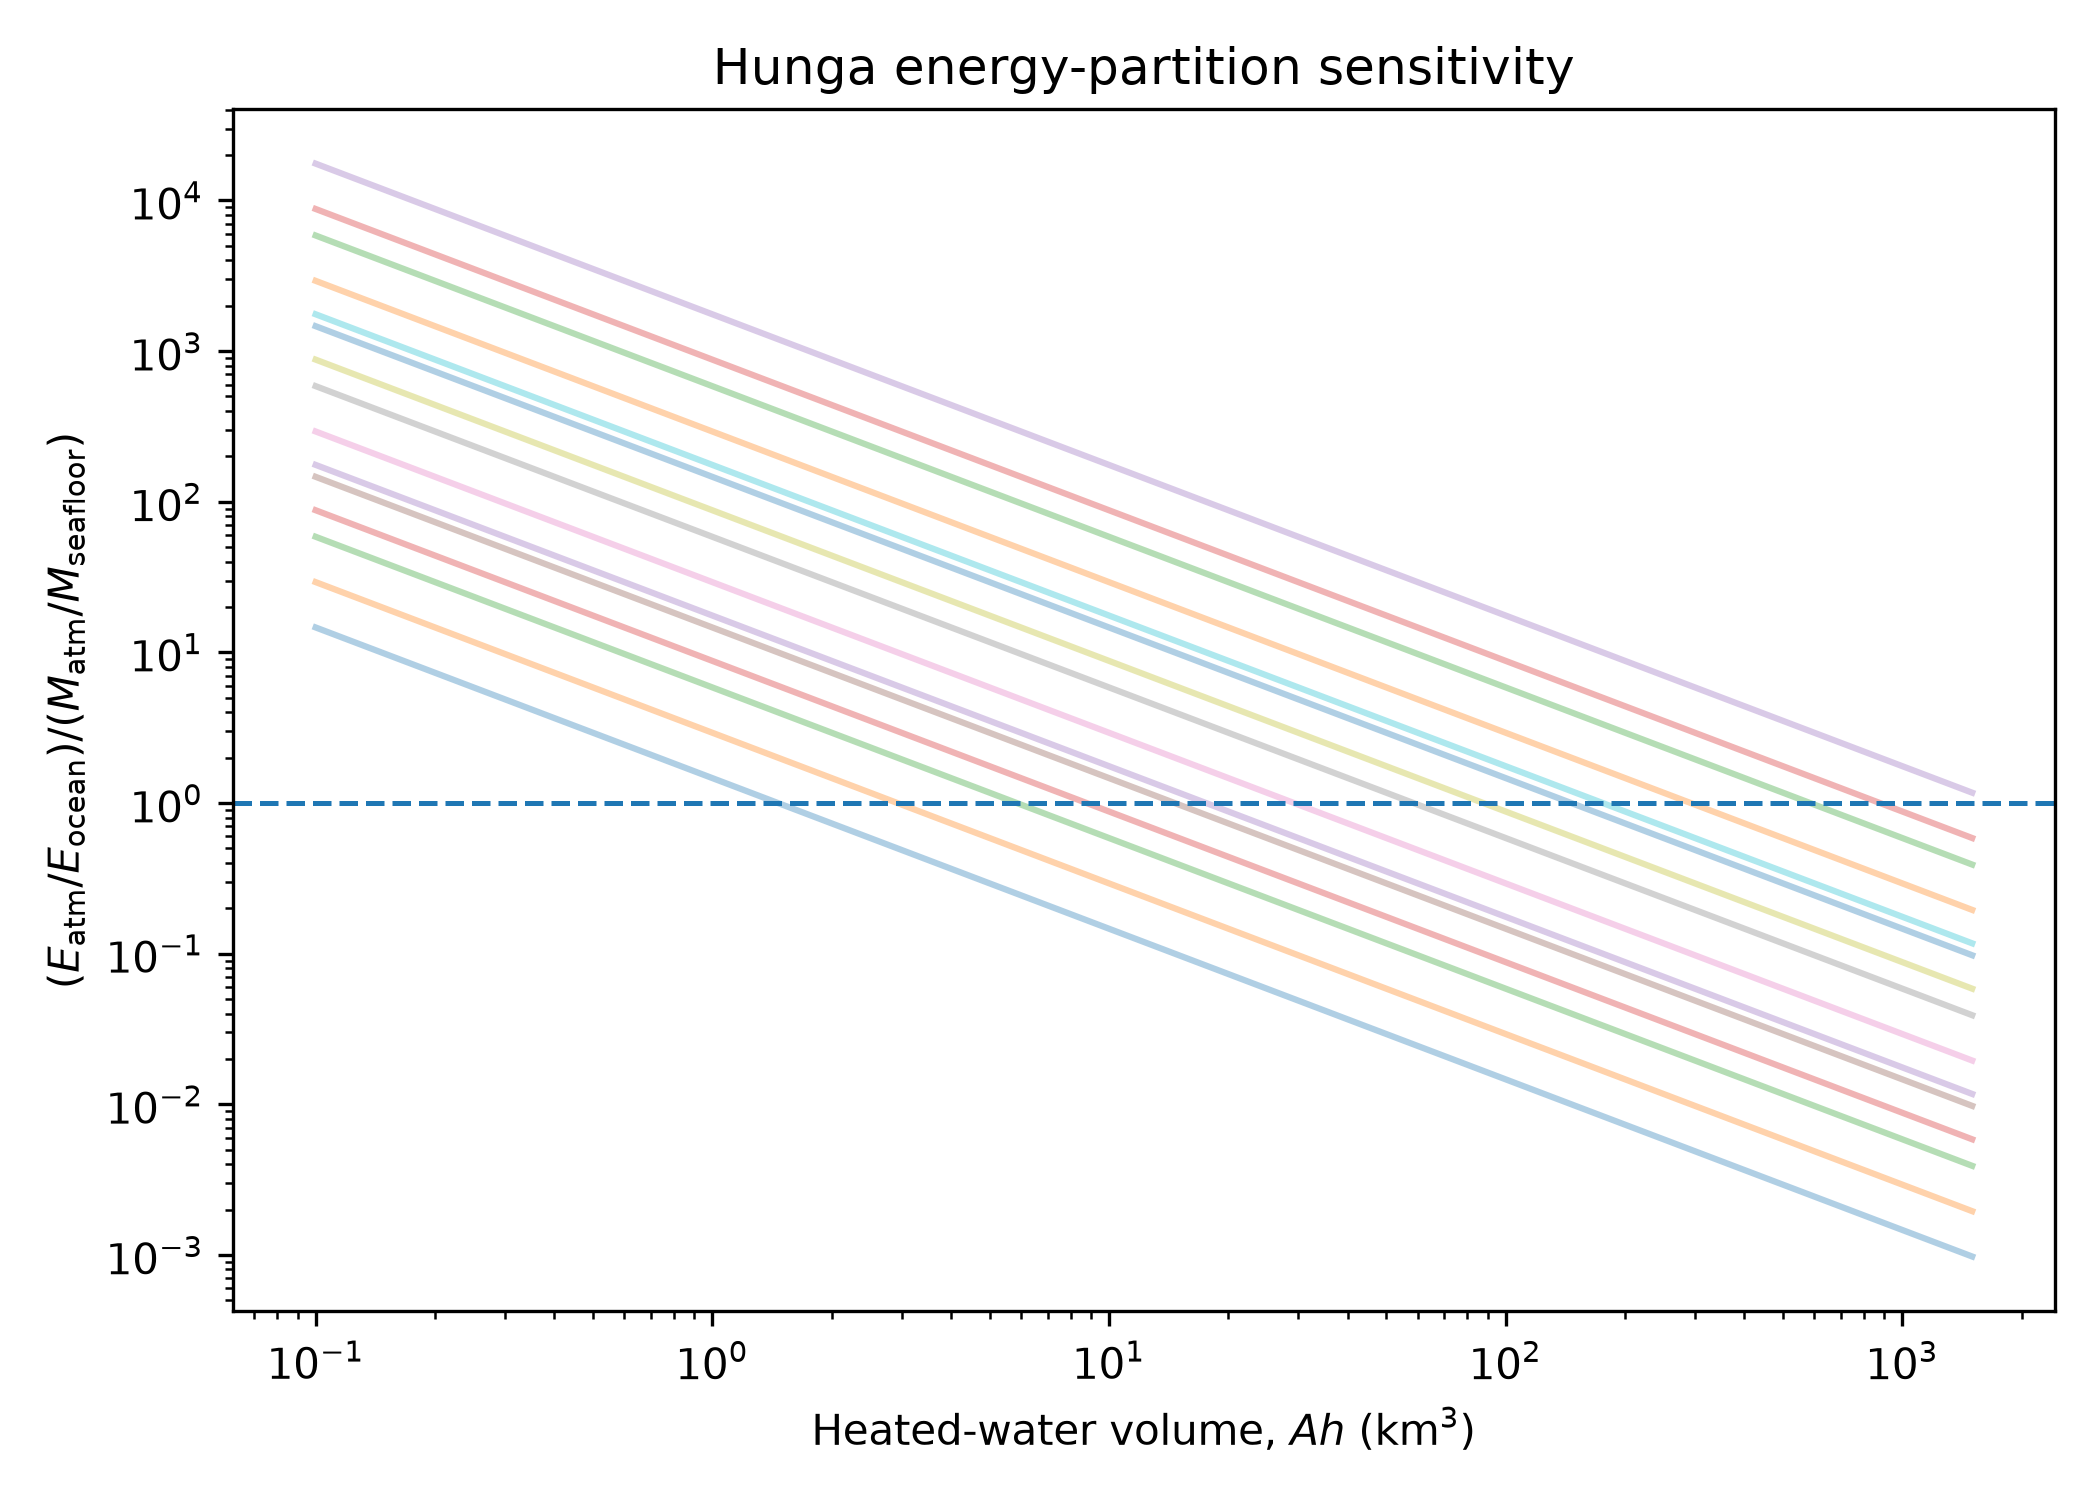

In [60]:
from IPython.display import Image, display

display(
    Image(
        filename='data/barone_2022/energy_partition_sensitivity.png'
    )
)


## Mastin liquid-water cases

Mastin et al. liquid-water source fractions are mapped into ThermoPlume using $\Omega=m_w/(1-m_w)$ and $n=m_g/(1-m_w)$. The seawater reference temperature is $25^\circ$C.


In [62]:
liquid_water_fractions = np.array([0.0, 0.05, 0.10, 0.20])
T_w0 = 298.15

liquid_rows = []

for m_w in liquid_water_fractions:
    Omega_liquid = m_w / (1.0 - m_w)
    n_liquid = m_g / (1.0 - m_w)

    p_liquid = ThermoPlumeParameters(
        Omega=Omega_liquid,
        n=n_liquid,
        T_m=T_m,
        T_w0=T_w0,
        Cp_m=Cp_m,
    )

    model_liquid = ThermoPlumeModel(p_liquid)

    a = model_liquid.solve(
        method='analytical',
        water_state='liquid',
    )

    py = model_liquid.solve(
        method='numerical',
        backend='python',
        water_state='liquid',
    )

    cpp = model_liquid.solve(
        method='numerical',
        backend='cpp',
        water_state='liquid',
    )

    liquid_rows.append({
        'water_fraction': m_w,
        'Omega': Omega_liquid,
        'n': n_liquid,
        'xi_analytical': a['xi_crit'],
        'xi_python': py['xi_crit'],
        'xi_cpp': cpp['xi_crit'],
        'regime': a['regime'],
    })

liquid_results = pd.DataFrame(liquid_rows)
liquid_results


,water_fraction,Omega,n,xi_analytical,xi_python,xi_cpp,regime
0,0.00,0.000000,0.030000,0.795192,0.795192,0.795192,dry
1,0.05,0.052632,0.031579,0.790650,0.790650,0.790650,C
2,0.10,0.111111,0.033333,0.773540,0.773540,0.773540,C
3,0.20,0.250000,0.037500,0.614954,0.614954,0.614954,C


## Liquid-water and steam-rich source comparison


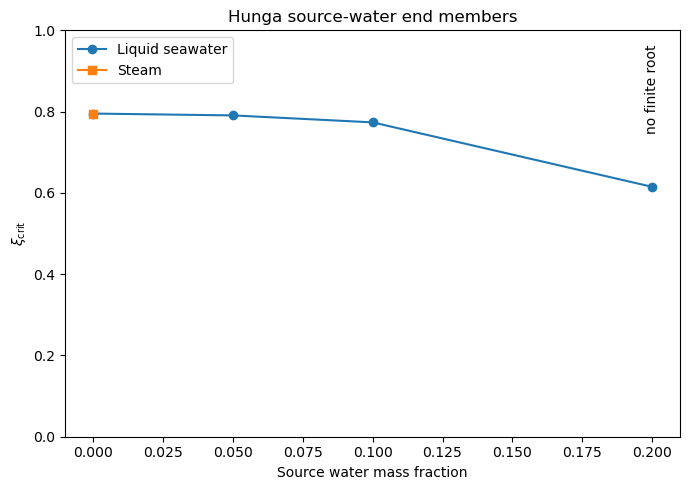

saved data/barone_2022/hunga_liquid_vs_vapor.png


In [64]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    liquid_results['water_fraction'],
    liquid_results['xi_analytical'],
    marker='o',
    label='Liquid seawater',
)

finite_vapor = np.isfinite(results['xi_analytical'])

ax.plot(
    results.loc[finite_vapor, 'steam_fraction'],
    results.loc[finite_vapor, 'xi_analytical'],
    marker='s',
    label='Steam',
)

for row in results.loc[~finite_vapor].itertuples(index=False):
    ax.annotate(
        'no finite root',
        xy=(row.steam_fraction, 0.98),
        xytext=(0, -4),
        textcoords='offset points',
        ha='center',
        va='top',
        rotation=90,
    )

ax.set_xlabel('Source water mass fraction')
ax.set_ylabel(r'$\xi_{\rm crit}$')
ax.set_ylim(0.0, 1.0)
ax.set_title('Hunga source-water end members')
ax.legend()

fig.tight_layout()

out = 'data/barone_2022/hunga_liquid_vs_vapor.png'
fig.savefig(out, dpi=300)
plt.show()

print(f'saved {out}')


## Mass and thermal-energy partition

Following the heat-budget idea, the atmospheric-to-ocean thermal-energy ratio is compared with the approximate erupted-material mass partition,

$$\mathcal{R}_E = \frac{E_{\rm atm}}{E_{\rm ocean}},$$

$$\mathcal{R}_M = \frac{M_{\rm atm}}{M_{\rm seafloor}} \approx \frac{1}{6}.$$

Because the warmed ocean area and heated depth are not uniquely constrained, the comparison is shown across the sensitivity space.


In [66]:
energy_partition = pd.read_csv(
    'data/barone_2022/energy_partition_sensitivity.csv'
)

energy_partition['heated_volume_km3'] = (
    energy_partition['area_km2']
    * energy_partition['heated_depth_m']
    / 1000.0
)

mass_ratio = 1.0 / 6.0

summary = (
    energy_partition.groupby('heated_volume_km3')
    ['E_atmosphere_over_E_ocean']
    .agg(['min', 'max'])
    .reset_index()
    .sort_values('heated_volume_km3')
)

summary


,heated_volume_km3,min,max
0,0.1,2.439024,2926.829268
1,0.3,0.813008,975.609756
2,0.5,0.487805,585.365854
3,1.0,0.243902,292.682927
4,1.5,0.162602,195.121951
5,2.0,0.121951,146.341463
6,3.0,0.081301,97.560976
7,5.0,0.048780,58.536585
8,6.0,0.040650,48.780488
9,10.0,0.024390,29.268293


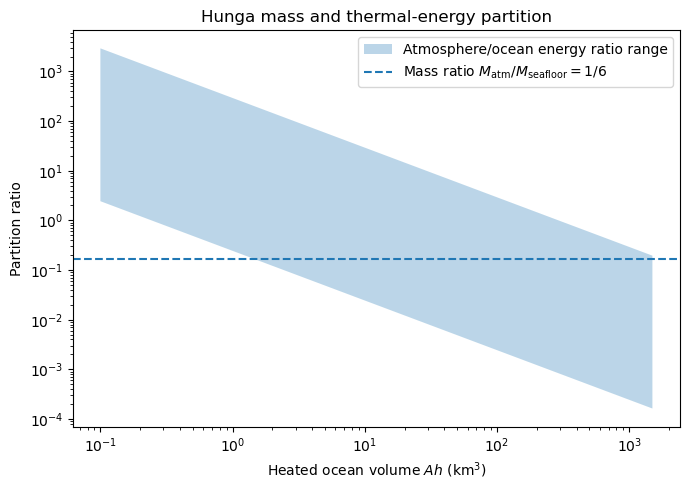

In [67]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.fill_between(
    summary['heated_volume_km3'],
    summary['min'],
    summary['max'],
    alpha=0.3,
    label='Atmosphere/ocean energy ratio range',
)

ax.axhline(
    mass_ratio,
    linestyle='--',
    label=r'Mass ratio $M_{\rm atm}/M_{\rm seafloor}=1/6$',
)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r'Heated ocean volume $Ah$ (km$^3$)')
ax.set_ylabel('Partition ratio')
ax.set_title('Hunga mass and thermal-energy partition')
ax.legend()

fig.tight_layout()
plt.show()


In [68]:
energy_partition['thermal_exceeds_mass'] = (
    energy_partition['E_atmosphere_over_E_ocean'] > mass_ratio
)

fraction_exceeding = energy_partition['thermal_exceeds_mass'].mean()

print(f'Cases with thermal partition > mass partition: {fraction_exceeding:.1%}')
print(
    'Energy-ratio range:',
    energy_partition['E_atmosphere_over_E_ocean'].min(),
    'to',
    energy_partition['E_atmosphere_over_E_ocean'].max(),
)


Cases with thermal partition > mass partition: 63.6%
Energy-ratio range: 0.0001626016260162 to 2926.829268292683


### Ocean heat-budget sensitivity

The Barone et al. SST anomaly lower bound is combined with a range of heated areas and depths to show the corresponding lower-bound ocean thermal energy.


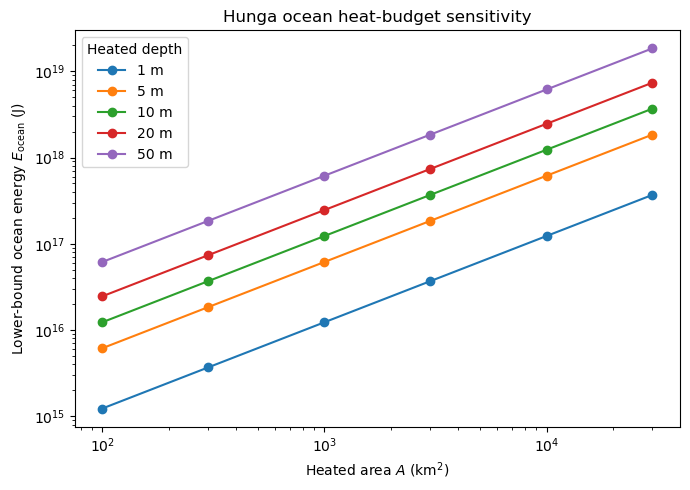

In [70]:
ocean_heat = pd.read_csv(
    'data/barone_2022/ocean_heat_budget_sensitivity.csv'
)

fig, ax = plt.subplots(figsize=(7, 5))

for depth, group in ocean_heat.groupby('heated_depth_m'):
    ax.plot(
        group['area_km2'],
        group['E_ocean_lower_bound_J'],
        marker='o',
        label=f'{depth:g} m',
    )

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'Heated area $A$ (km$^2$)')
ax.set_ylabel(r'Lower-bound ocean energy $E_{\rm ocean}$ (J)')
ax.set_title('Hunga ocean heat-budget sensitivity')
ax.legend(title='Heated depth')

fig.tight_layout()
plt.show()


### Atmospheric energy sensitivity


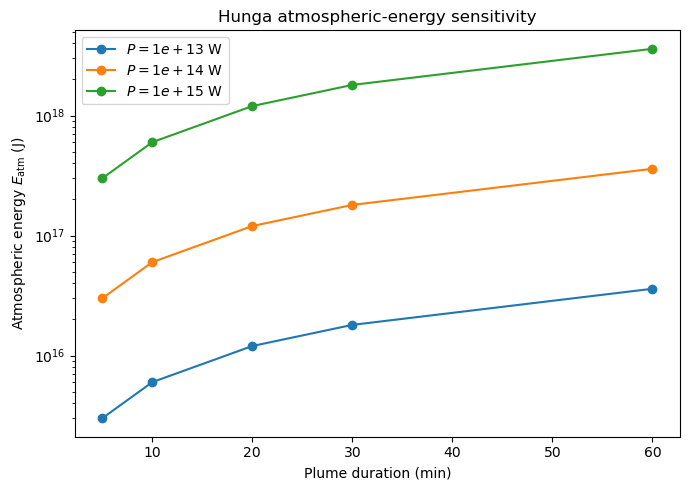

In [72]:
atm = (
    energy_partition[
        ['plume_power_W', 'duration_min', 'E_atmosphere_J']
    ]
    .drop_duplicates()
    .sort_values(['plume_power_W', 'duration_min'])
)

fig, ax = plt.subplots(figsize=(7, 5))

for power, group in atm.groupby('plume_power_W'):
    ax.plot(
        group['duration_min'],
        group['E_atmosphere_J'],
        marker='o',
        label=fr'$P={power:.0e}$ W',
    )

ax.set_yscale('log')
ax.set_xlabel('Plume duration (min)')
ax.set_ylabel(r'Atmospheric energy $E_{\rm atm}$ (J)')
ax.set_title('Hunga atmospheric-energy sensitivity')
ax.legend()

fig.tight_layout()
plt.show()


## Hunga heat and mass budget summary


In [74]:
summary_budget = pd.DataFrame({
    'quantity': [
        'Atmosphere/seafloor mass ratio',
        'Ocean energy lower-bound minimum',
        'Ocean energy lower-bound maximum',
        'Atmospheric energy minimum',
        'Atmospheric energy maximum',
        'Atmosphere/ocean energy ratio minimum',
        'Atmosphere/ocean energy ratio maximum',
    ],
    'value': [
        mass_ratio,
        ocean_heat['E_ocean_lower_bound_J'].min(),
        ocean_heat['E_ocean_lower_bound_J'].max(),
        energy_partition['E_atmosphere_J'].min(),
        energy_partition['E_atmosphere_J'].max(),
        energy_partition['E_atmosphere_over_E_ocean'].min(),
        energy_partition['E_atmosphere_over_E_ocean'].max(),
    ],
    'units': [
        'dimensionless',
        'J',
        'J',
        'J',
        'J',
        'dimensionless',
        'dimensionless',
    ],
})

summary_budget


,quantity,value,units
0,Atmosphere/seafloor mass ratio,1.666667e-01,dimensionless
1,Ocean energy lower-bound minimum,1.230000e+15,J
2,Ocean energy lower-bound maximum,1.845000e+19,J
3,Atmospheric energy minimum,3.000000e+15,J
4,Atmospheric energy maximum,3.600000e+18,J
5,Atmosphere/ocean energy ratio minimum,1.626016e-04,dimensionless
6,Atmosphere/ocean energy ratio maximum,2.926829e+03,dimensionless


## Interpretation

The ThermoPlume calculations show a strong contrast between liquid-water and steam-rich source conditions. For the vapor-rich Hunga end members, sufficiently large steam fractions eliminate a finite neutral-buoyancy root, indicating that the source mixture remains on the buoyant side of the reduced thermodynamic criterion across the admissible composition range.

The first-order heat-budget calculation provides a complementary eruption-scale perspective. Using the Barone et al. SST anomaly lower bound, the inferred ocean thermal energy depends primarily on the uncertain warmed area and heated depth, while atmospheric energy depends on plume power and duration. Comparing the atmospheric-to-ocean energy ratio with the approximate atmospheric-to-seafloor mass ratio tests whether thermal energy was partitioned disproportionately toward the atmospheric plume relative to erupted mass.

## Testing the 90% steam hypothesis

The discrete Mastin steam cases show whether a 90% steam source is thermodynamically compatible with sustained buoyancy, but they do not show whether 90% steam is uniquely required. To test this, the vapor-only criterion is evaluated continuously from dry conditions to 90% steam. The key diagnostic is the steam fraction at which the finite neutral-buoyancy root disappears.


In [77]:
steam_sweep = np.linspace(0.0, 0.90, 901)

sweep_rows = []

for m_s in steam_sweep:
    Omega_s = m_s / (1.0 - m_s)
    n_s = m_g / (1.0 - m_s)

    p_s = ThermoPlumeParameters(
        Omega=Omega_s,
        n=n_s,
        T_m=T_m,
        T_w=T_w,
        Cp_m=Cp_m,
    )

    model_s = ThermoPlumeModel(p_s)

    sol = model_s.solve(
        method='analytical',
        water_state='vapor',
    )

    sweep_rows.append({
        'steam_fraction': m_s,
        'Omega': Omega_s,
        'n': n_s,
        'xi_crit': sol['xi_crit'],
    })

steam_sweep_results = pd.DataFrame(sweep_rows)

finite = np.isfinite(steam_sweep_results['xi_crit'])

if (~finite).any():
    first_no_root = steam_sweep_results.loc[
        ~finite,
        'steam_fraction',
    ].iloc[0]
else:
    first_no_root = np.nan

print(f'First no-root steam fraction: {first_no_root:.3f}')
print(f'Mastin 90% case: {0.90:.3f}')

steam_sweep_results.head()


First no-root steam fraction: 0.118
Mastin 90% case: 0.900


,steam_fraction,Omega,n,xi_crit
0,0.000,0.000000,0.03000,0.795192
1,0.001,0.001001,0.03003,0.795786
2,0.002,0.002004,0.03006,0.796382
3,0.003,0.003009,0.03009,0.796980
4,0.004,0.004016,0.03012,0.797580


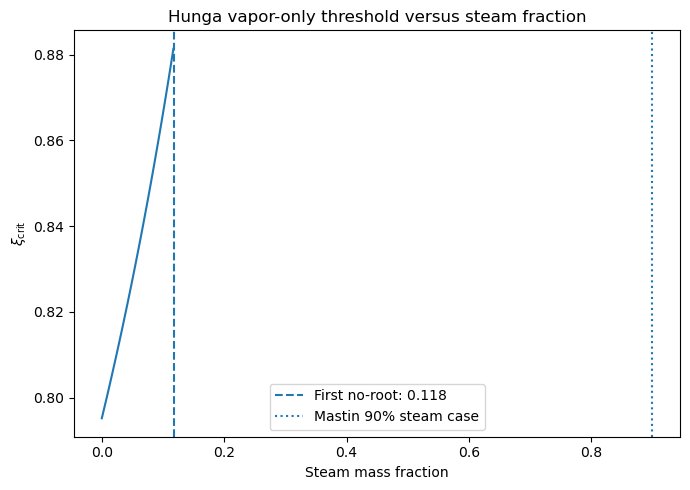

In [78]:
fig, ax = plt.subplots(figsize=(7, 5))

finite = np.isfinite(steam_sweep_results['xi_crit'])

ax.plot(
    steam_sweep_results.loc[finite, 'steam_fraction'],
    steam_sweep_results.loc[finite, 'xi_crit'],
)

if np.isfinite(first_no_root):
    ax.axvline(
        first_no_root,
        linestyle='--',
        label=f'First no-root: {first_no_root:.3f}',
    )

ax.axvline(
    0.90,
    linestyle=':',
    label='Mastin 90% steam case',
)

ax.set_xlabel('Steam mass fraction')
ax.set_ylabel(r'$\xi_{\rm crit}$')
ax.set_title('Hunga vapor-only threshold versus steam fraction')
ax.legend()

fig.tight_layout()
plt.show()
